In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
#BASIC LIBRARIES
import pandas as pd
import numpy as np

#Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Evaluation libraries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

#Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [3]:
#!pip install tensorflow==2.15.0

In [4]:
#Dataset Loading (digit mnist)
(X_train_digit,y_train_digit),(X_test_digit,y_test_digit) = mnist.load_data()

In [5]:
X_train_digit

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [6]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

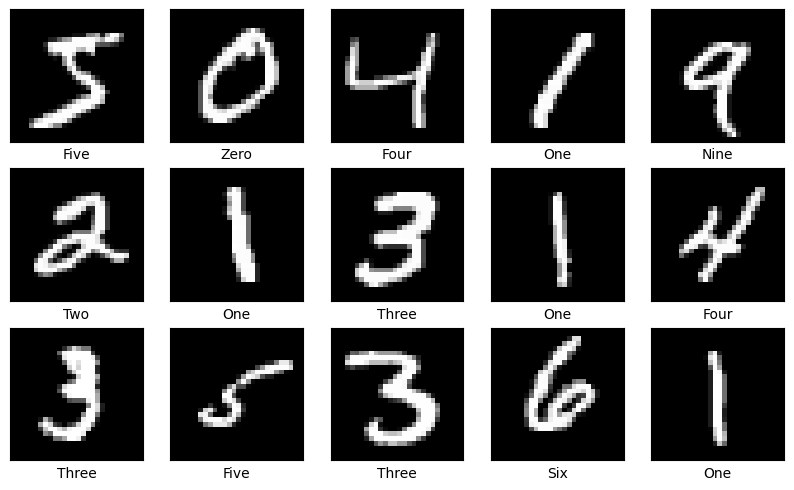

In [7]:
#names of numbers in the dataset in order
col_names= ['Zero', 'One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

# Visualization of data
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_digit[i],cmap='gray')
    plt.xlabel(col_names[y_train_digit[i]])
plt.show()

In [8]:
#checking X_train_digit data 
X_train_digit.shape 

(60000, 28, 28)

In [9]:
X_test_digit.shape

(10000, 28, 28)

In [10]:
#Reduce 3D data to 2D for ANN process
X_train_digit = X_train_digit.reshape(60000,784)
X_test_digit = X_test_digit.reshape(10000,784)

In [11]:
X_train_digit.shape

(60000, 784)

In [12]:
#Checking same with Y train and test data - 1D to 2D 
y_train_digit.shape

(60000,)

In [13]:
y_test_digit[1]

2

In [14]:
#Encoding digit mnist labels using one hot encoding for ANN
y_train_digit = to_categorical(y_train_digit,num_classes = 10)
y_test_digit = to_categorical(y_test_digit, num_classes = 10)

In [15]:
y_train_digit.shape

(60000, 10)

In [16]:
y_test_digit[1]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [17]:
#Creating base for neural network
model = keras.Sequential([layers.Dense(256,activation = 'relu',input_shape = (784,)),
                          layers.Dense(64,activation = 'relu'),
                          layers.Dense(64,activation = 'relu'),
                          layers.Dense(10,activation = 'sigmoid')])

In [18]:
#Denselayer param_num = output_channel_number *(input_channel_num +1)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               200960    
                                                                 
 dense_1 (Dense)             (None, 64)                16448     
                                                                 
 dense_2 (Dense)             (None, 64)                4160      
                                                                 
 dense_3 (Dense)             (None, 10)                650       
                                                                 
Total params: 222218 (868.04 KB)
Trainable params: 222218 (868.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [19]:
#compiling the model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics = ['accuracy'])

In [20]:
#model learning
history  = model.fit(X_train_digit,y_train_digit,batch_size=100,epochs=10,validation_data=(X_test_digit,y_test_digit))

Epoch 1/10


600/600 [==============================] - 8s 9ms/step - loss: 1.4259 - accuracy: 0.8336 - val_loss: 0.3789 - val_accuracy: 0.9036
Epoch 2/10
600/600 [==============================] - 5s 8ms/step - loss: 0.2827 - accuracy: 0.9271 - val_loss: 0.2587 - val_accuracy: 0.9310
Epoch 3/10
600/600 [==============================] - 5s 8ms/step - loss: 0.1852 - accuracy: 0.9491 - val_loss: 0.2310 - val_accuracy: 0.9403
Epoch 4/10
600/600 [==============================] - 5s 8ms/step - loss: 0.1489 - accuracy: 0.9579 - val_loss: 0.2191 - val_accuracy: 0.9467
Epoch 5/10
600/600 [==============================] - 5s 8ms/step - loss: 0.1254 - accuracy: 0.9647 - val_loss: 0.1819 - val_accuracy: 0.9568
Epoch 6/10
600/600 [==============================] - 5s 8ms/step - loss: 0.1208 - accuracy: 0.9657 - val_loss: 0.1993 - val_accuracy: 0.9497
Epoch 7/10
600/600 [==============================] - 5s 8ms/step - loss: 0.1059 - accuracy: 0.9694 - val_loss: 0.1650 - val_accuracy: 0.9593
Epoc

In [21]:
#predicting the labels_digit
y_predict = model.predict(X_test_digit)
y_predict

313/313 [==============================] - 1s 3ms/step


array([[1.5733436e-03, 8.3405536e-01, 9.9917352e-01, ..., 1.0000000e+00,
        1.8926546e-02, 9.9998420e-01],
       [4.9663132e-01, 9.7085398e-01, 1.0000000e+00, ..., 9.9777400e-01,
        7.3226392e-01, 2.4832934e-02],
       [7.3793689e-03, 1.0000000e+00, 1.5702002e-01, ..., 9.9812907e-01,
        9.8075593e-01, 2.2799551e-01],
       ...,
       [7.6893759e-01, 7.8109115e-01, 9.7745210e-01, ..., 9.9713504e-01,
        9.9998862e-01, 1.0000000e+00],
       [2.5058595e-09, 5.4378217e-11, 8.9311342e-10, ..., 1.2210019e-13,
        1.9266408e-02, 3.7552743e-09],
       [9.8772109e-01, 3.3368171e-06, 7.7656603e-01, ..., 1.1653031e-14,
        7.3112071e-01, 1.6827403e-08]], dtype=float32)

In [22]:
#Here we get the index of maximum value in the encoded vector.
y_predicts = np.argmax(y_predict,axis=1)
y_test_digit_eval = np.argmax(y_test_digit,axis=1)

In [23]:
y_predicts

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [24]:
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

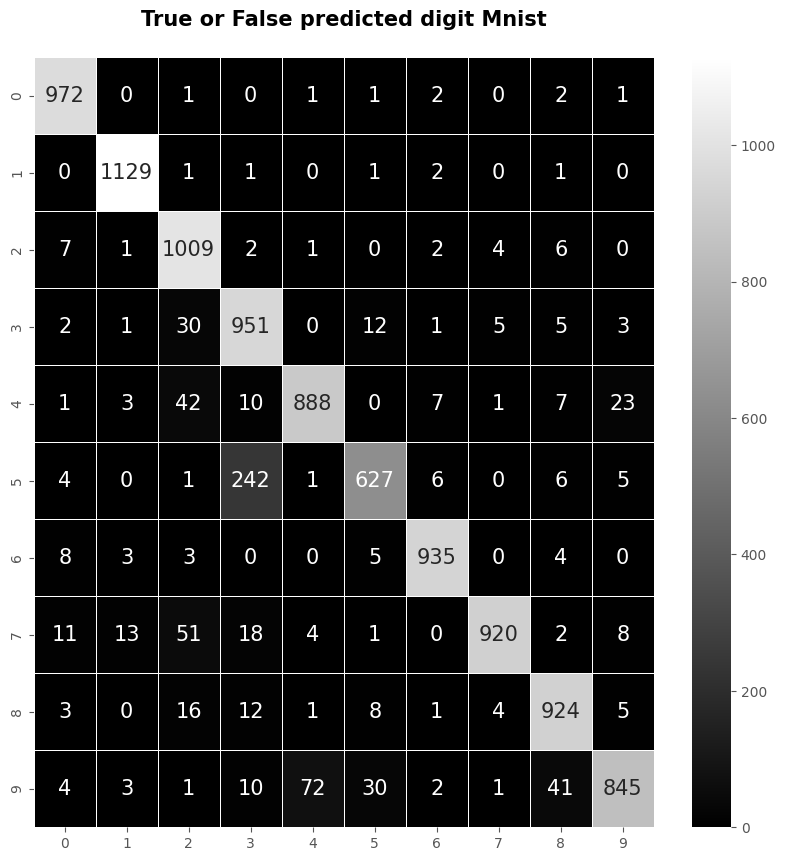

In [25]:
#Confusion matrix for digit mnist
con_mat = confusion_matrix(y_test_digit_eval,y_predicts)
plt.style.use('ggplot')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidths=0.5,fmt='d',cmap='gray')
plt.title('True or False predicted digit Mnist\n', fontweight='bold',fontsize=15)
plt.show()

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test_digit_eval,y_predicts))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.87      0.98      0.92      1032
           3       0.76      0.94      0.84      1010
           4       0.92      0.90      0.91       982
           5       0.92      0.70      0.80       892
           6       0.98      0.98      0.98       958
           7       0.98      0.89      0.94      1028
           8       0.93      0.95      0.94       974
           9       0.95      0.84      0.89      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



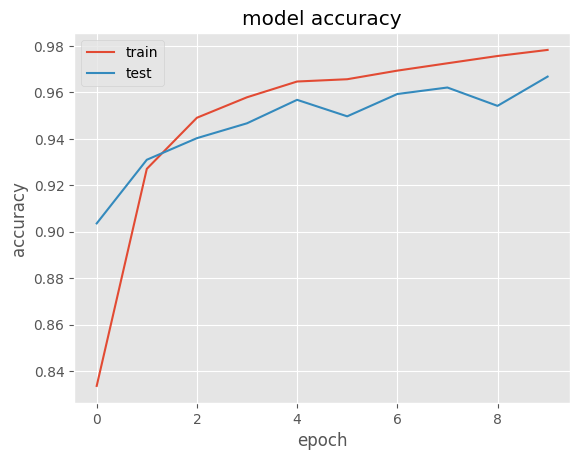

In [27]:
#summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='best')
plt.show()

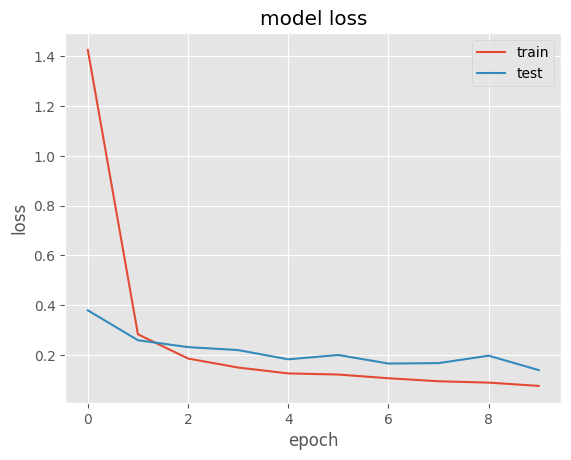

In [28]:
#summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='best')
plt.show()

In [29]:
#single image checking
y_predict_single = model.predict(X_test_digit[[2]])
y_predicts_single = np.argmax(y_predict_single,axis=1)
y_test_digit_eval = np.argmax(y_test_digit,axis=1)

1/1 [==============================] - 0s 44ms/step


In [30]:
y_predicts_single[0]

1

In [31]:
y_test_digit_eval[2]

1

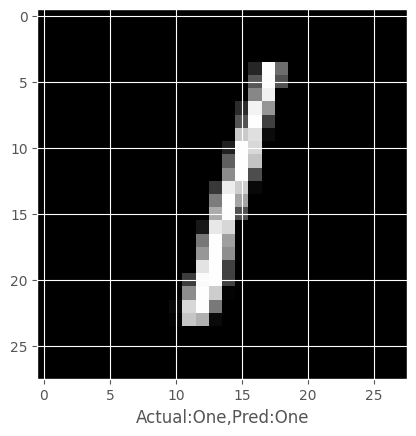

In [32]:
#Names of numbers in the dataset  in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']
#visualization the digits
#plt.figure(figsize=(10,10))
plt.imshow(X_test_digit[2].reshape(28,28),cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[y_test_digit_eval[2]],col_names[y_predicts_single[0]]))
plt.show()